# Load data from spatial analysis

In [18]:
import pandas as pd
import numpy as np

df = pd.read_parquet("../data/processed/station_spatial_summary.parquet")
print(df.shape)
df.head()

(2160, 17)


,start_station_id,total_trips,casual_trips,member_trips,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour,start_lat,start_lng,start_station_name,gi_zscore,gi_pvalue,hotspot_category
0,2009.04,221,124,97,0.561086,2190.059194,1280.789794,1.260496,2.356308,0.438914,20,40.61150,-74.03513,Shore Rd & 4 Ave,1.716563,0.001,hot spot
1,2158.08,197,56,141,0.284264,1188.031786,831.328362,1.315942,2.146326,0.248731,19,40.61689,-74.03091,4 Ave & 94 St,2.058648,0.001,hot spot
2,2190.08,195,71,124,0.364103,1471.565577,1297.978427,2.855367,4.115211,0.246154,14,40.61717,-74.02744,Fort Hamilton Pkwy & 92 St,1.621762,0.002,hot spot
3,2231.10,155,68,87,0.438710,1098.562206,899.890874,2.046109,2.715366,0.374194,7,40.61946,-74.03261,3 Ave & 92 St,1.410858,0.005,hot spot
4,2240.06,170,83,87,0.488235,1366.095120,914.267575,1.550043,2.259779,0.305882,19,40.61919,-74.04020,Shore Rd & Oliver St,1.915443,0.001,hot spot


# Select and prepare clustering features

In [19]:
print(df.columns.tolist())

['start_station_id', 'total_trips', 'casual_trips', 'member_trips', 'casual_share', 'avg_duration_casual', 'avg_duration_member', 'avg_distance_casual', 'avg_distance_member', 'weekend_trip_share', 'peak_hour', 'start_lat', 'start_lng', 'start_station_name', 'gi_zscore', 'gi_pvalue', 'hotspot_category']


In [20]:
# convert peak_hour to cyclical sin/cos components so hour 23 and hour 0
# are treated as close together, not far apart
df['peak_hour_sin'] = np.sin(2 * np.pi * df['peak_hour'] / 24)
df['peak_hour_cos'] = np.cos(2 * np.pi * df['peak_hour'] / 24)

In [21]:
cluster_features = [
    'casual_share',
    'avg_duration_casual',
    'avg_duration_member',
    'avg_distance_casual',
    'avg_distance_member',
    'weekend_trip_share',
    'peak_hour_sin',
    'peak_hour_cos',
]

X = df[cluster_features].copy()
print(X.shape)
X.describe()

(2160, 8)


,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos
count,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2.160000e+03
mean,0.221933,1096.715593,747.751865,2.244143,2.137291,0.254828,-0.529843,-2.569685e-01
std,0.072297,288.945563,137.563942,0.474882,0.448584,0.052562,0.724689,3.582771e-01
min,0.070784,495.205539,459.519805,0.259884,0.373804,0.000000,-1.000000,-1.000000e+00
25%,0.173314,915.104382,665.283185,1.963617,1.846168,0.224763,-1.000000,-5.000000e-01
50%,0.206988,1033.106634,728.250103,2.225227,2.092550,0.255400,-0.965926,-2.588190e-01
75%,0.253508,1211.278530,800.502421,2.483442,2.367313,0.286292,-0.500000,-1.836970e-16
max,0.724171,3334.499419,1877.748475,6.367784,5.183059,0.590303,1.000000,1.000000e+00


In [22]:
# check for any missing values before scaling — clustering can't handle NaN
X.isna().sum()

casual_share           0
avg_duration_casual    0
avg_duration_member    0
avg_distance_casual    0
avg_distance_member    0
weekend_trip_share     0
peak_hour_sin          0
peak_hour_cos          0
dtype: int64

# Scale the features

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# quick check: scaled features should have mean ~0, std ~1
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe()

,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos
count,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03,2.160000e+03
mean,-5.263280e-17,-3.750087e-16,-6.315935e-16,-3.289550e-16,7.500173e-16,-1.052656e-16,-1.365163e-16,1.184238e-16
std,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00,1.000232e+00
min,-2.091150e+00,-2.082224e+00,-2.095744e+00,-4.179395e+00,-3.932141e+00,-4.849280e+00,-6.489215e-01,-2.074382e+00
25%,-6.726436e-01,-6.286764e-01,-5.996322e-01,-5.908652e-01,-6.491330e-01,-5.721396e-01,-6.489215e-01,-6.784910e-01
50%,-2.067517e-01,-2.201926e-01,-1.417979e-01,-3.984178e-02,-9.976269e-02,1.086737e-02,-6.018916e-01,-5.166422e-03
75%,4.368450e-01,3.965780e-01,3.835509e-01,5.040292e-01,5.128914e-01,5.987432e-01,4.118940e-02,7.173999e-01
max,6.948507e+00,7.746449e+00,8.216239e+00,8.685522e+00,6.791310e+00,6.383943e+00,2.111522e+00,3.509182e+00


# Choose the number of clusters

In [25]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

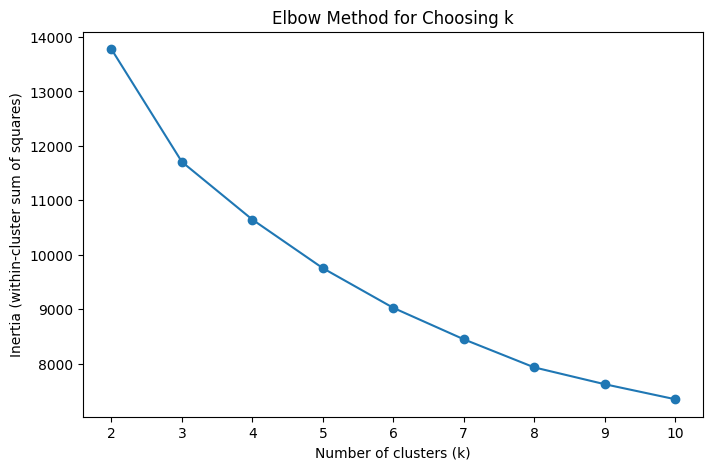

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Choosing k')
plt.show()

In [27]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette score = {s:.3f}")

/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

k=2: silhouette score = 0.250
k=3: silhouette score = 0.226
k=4: silhouette score = 0.179
k=5: silhouette score = 0.187
k=6: silhouette score = 0.176
k=7: silhouette score = 0.189
k=8: silhouette score = 0.187
k=9: silhouette score = 0.189
k=10: silhouette score = 0.160


# Run k-means clustering

In [28]:
K = 2  # set based on the elbow plot and silhouette scores above — adjust after reviewing them
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/ameliatuttle/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountere

In [29]:
df['cluster'].value_counts().sort_index()

cluster
0    1565
1     595
Name: count, dtype: int64

# Profile each cluster

In [30]:
profile_cols = cluster_features + ['casual_share', 'total_trips']
cluster_profile = df.groupby('cluster')[profile_cols].mean()
cluster_profile

,casual_share,avg_duration_casual,avg_duration_member,avg_distance_casual,avg_distance_member,weekend_trip_share,peak_hour_sin,peak_hour_cos,casual_share,total_trips
cluster,,,,,,,,,,
0,0.202449,1014.009195,692.348663,2.104812,1.958721,0.243037,-0.491596,-0.274128,0.202449,2704.212780
1,0.273178,1314.254268,893.476253,2.610619,2.606976,0.285844,-0.630440,-0.211834,0.273178,1888.152941


In [31]:
# view sample station names per cluster to build intuition for what each represents
for c in sorted(df['cluster'].unique()):
    print(f"\nCluster {c} sample stations:")
    print(df[df['cluster'] == c]['start_station_name'].head(10).tolist())


Cluster 0 sample stations:
['4 Ave & 94 St', '4 Ave & 87 St', '89 St & 3 Ave', '86 St & Ridge Blvd', '84 St & 3 Ave', '6 Ave & 78 St', '3 Ave & 81 St', '83 St & Narrows Ave', '6 Ave & 74 St', '3 Ave & 77 St']

Cluster 1 sample stations:
['Shore Rd & 4 Ave', 'Fort Hamilton Pkwy & 92 St', '3 Ave & 92 St', 'Shore Rd & Oliver St', '5 Ave & 88 St', 'Fort Hamilton Pkwy & 85 St', '4 Ave & 85 St', '4 Ave & 81 St', '79 St & 5 Ave', '4 Ave & 76 St']


# Cross-check clusters against hotspots

In [32]:
pd.crosstab(df['cluster'], df['hotspot_category'])

hotspot_category,cold spot,hot spot,not significant
cluster,,,
0,541,135,889
1,39,173,383


In [33]:
# same thing as proportions within each cluster, easier to read
pd.crosstab(df['cluster'], df['hotspot_category'], normalize='index')

hotspot_category,cold spot,hot spot,not significant
cluster,,,
0,0.345687,0.086262,0.568051
1,0.065546,0.290756,0.643697


# Save results